In [1]:
%load_ext autoreload
%autoreload 2

import warnings 
from pathlib import Path

import jax
jax.config.update("jax_enable_x64", True)

import pandas as pd
import seaborn as sns

from training import RES_DIR
from source.visuals import COLORS, plot_multi_xy_list
from source.general_functions import create_dir_if_not_exists, query_df

sns.set_theme()
warnings.filterwarnings("ignore")

## Analysis:

#### Q1. Is linearization useful for LA-BTN?

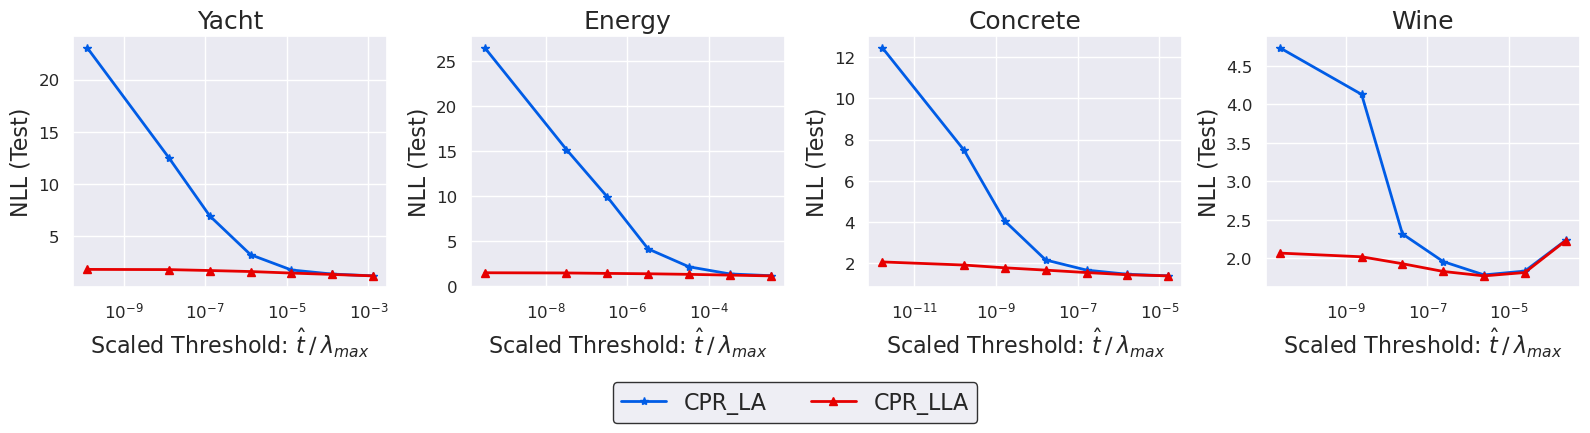

In [2]:
HESS_TYPE = 'gauss_newton'
SCALED_TH_BOOL = True

SAVE_DIR = Path(f'./artifacts/results/Q1_LLAvsLA/')
create_dir_if_not_exists(SAVE_DIR)

x_name, y_name = 'hess_th', 'nll_test'
model_name_list = ['cpr_la', 'cpr_lla']
data_name_list = ['yacht', 'energy', 'concrete', 'wine_red']
multi_x_lists, multi_y_lists, multi_legend_lists, titles = [], [], [], []
for data_name in data_name_list:
    x_list, y_list, leg_list = [], [], []
    for model_name in model_name_list:
        res_dir = RES_DIR / f'{model_name}/{data_name}/'
        res_df = pd.read_csv(res_dir / 'nll_info.csv', index_col=0)
        tdf = query_df(res_df, dict(hess_type=HESS_TYPE)).sort_values(by=x_name)
        max_hess_ev = tdf['max_ev'].unique().item()
        y_list.append(tdf[y_name].to_list())
        leg_list.append(model_name.upper())
        if SCALED_TH_BOOL:
            x_list.append((tdf[x_name] / max_hess_ev).to_list())
        else:
            x_list.append(tdf[x_name].to_list())
    multi_x_lists.append(x_list)
    multi_y_lists.append(y_list)
    multi_legend_lists.append(leg_list)
    titles.append(data_name.split('_')[0].capitalize())

xlabel = (
    r'Scaled Threshold: $\hat{t} \slash \lambda_{max}$' 
    if SCALED_TH_BOOL else r'Threshold - $\hat{t}$'
)
color_list = [COLORS['blue'], COLORS['red']]
marker_list = ['*', '^']
save_path = (
    SAVE_DIR / f'linearization_scaled_th.png' 
    if SCALED_TH_BOOL else SAVE_DIR / f'linearization_th.png'
)
plot_multi_xy_list(multi_x_lists, multi_y_lists, multi_legend_lists, titles,
    color_list=color_list,
    marker_list=marker_list,
    xlabel=xlabel,
    ylabel='NLL (Test)',
    ncols=4,
    x_scale='log', 
    y_scale='linear',
    figsize=(16, 4),
    save_path=save_path,
    dpi=600,
)

#### Q2: What Hessian approximation to choose?

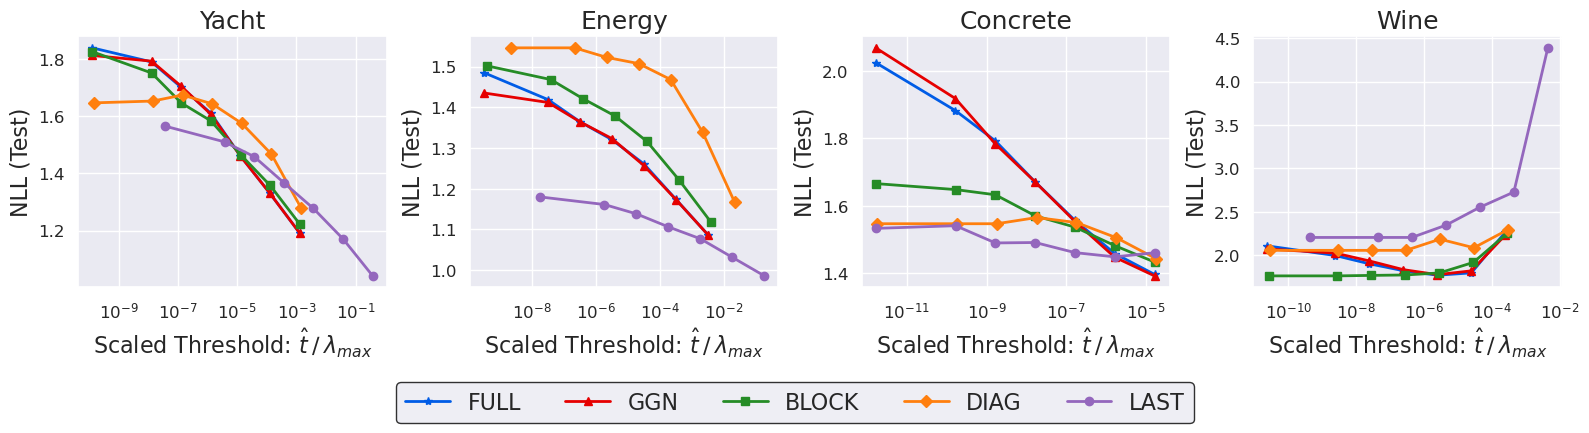

In [3]:
SCALED_TH_BOOL = True

SAVE_DIR = Path(f'./artifacts/results/Q2_HessMode/')
create_dir_if_not_exists(SAVE_DIR)

model_name = 'cpr_lla'
x_name, y_name = 'hess_th', 'nll_test'
data_name_list = ['yacht', 'energy', 'concrete', 'wine_red']
multi_x_lists, multi_y_lists, multi_legend_lists, titles = [], [], [], []
for data_name in data_name_list:
    res_dir = RES_DIR / f'{model_name}/{data_name}/'
    res_df = pd.read_csv(res_dir / 'nll_info.csv', index_col=0)
    x_list, y_list, leg_list = [], [], []
    for hess_type in ['full', 'gauss_newton', 'block', 'mf', 'last']:
        tdf = query_df(res_df, dict(hess_type=hess_type)).sort_values(by=x_name)
        max_hess_ev = tdf['max_ev'].unique().item()
        y_list.append(tdf[y_name].to_list())
        if hess_type == 'gauss_newton':
            leg_list.append('GGN')
        elif hess_type == 'mf':
            leg_list.append('DIAG')
        else:
            leg_list.append(hess_type.upper())
        if SCALED_TH_BOOL:
            x_list.append((tdf[x_name] / max_hess_ev).to_list())
        else:
            x_list.append(tdf[x_name].to_list())
    multi_x_lists.append(x_list)
    multi_y_lists.append(y_list)
    multi_legend_lists.append(leg_list)
    titles.append(data_name.split('_')[0].capitalize())

xlabel = (
    r'Scaled Threshold: $\hat{t} \slash \lambda_{max}$' 
    if SCALED_TH_BOOL else r'Threshold - $\hat{t}$'
)
color_list = [
    COLORS['blue'], COLORS['red'], COLORS['green'], 
    COLORS['orange'], COLORS['purple']
]
marker_list = ['*', '^', 's', 'D', 'o']
save_path = (
    SAVE_DIR / f'hess_mode_scaled_th.png' 
    if SCALED_TH_BOOL else SAVE_DIR / f'hess_mode_th.png'
)
plot_multi_xy_list(multi_x_lists, multi_y_lists, multi_legend_lists, titles,
    color_list=color_list,
    marker_list=marker_list,
    xlabel=xlabel,
    ylabel='NLL (Test)',
    x_scale='log',
    y_scale='linear',
    figsize=(16, 4),
    ncols=4,
    save_path=save_path,
    dpi=600,
)